# Сравнение подходов для извлечения и сопоставления ключевых точек

Сравним несколько подходов, используя следующую метрику:

$$ M_k = \frac{1}{k - 1} \cdot \sum_{j=1}^{k-1} \frac{m_{0,j}}{N_j \cdot (1 - j \cdot \alpha)} $$

где $ M_k $ -усредненная доля правильно сопоставленных ключевых точек на окне из k кадров, $ m_{0,j} $ - количество сопоставлений начального кадра окна с j-ым кадром, $ N_j $ - общее количество выделенных ключевых точек на j-ом кадре, $ \alpha $ - коэффицент, определяющий долю различающейся площади между двумя соседними кадрами.

Для простоты сравнения пока рассмотрим равномерное прямолинейное движение беспилотника. Также будем считать что камера направлена вдоль оси Z и что оси X и Y определяют плоскость изображения.

## Нахождение $ \alpha $ для выбранного набора кадров

С помощью библиотеки `geopy` по координатам на изображениях рассчитаем, сколько примерно пролетает беспилотник, для того чтобы заснять полностью новый кадр.

In [ ]:
from geopy.distance import geodesic

frame1501 = (56.659766, 38.997759)
frame1660 = (56.659317, 38.998079)
frame1555 = (56.659614, 38.997866)
frame1708 = (56.659183, 38.998174)
frame1717 = (56.659158, 38.998192)
frame1873 = (56.658724, 38.998499)

x1 = geodesic(frame1501, frame1660).meters
x2 = geodesic(frame1555, frame1708).meters
x3 = geodesic(frame1717, frame1873).meters

print(x1)
print(x2)
print(x3)
print()
print("Среднее расстояние: {:.2f} метров".format((x1 + x2 + x3) / 3))


53.711251170899004
51.576626990293036
51.86541089702435

Среднее расстояние: 52.38 метров


Зная, что смещение между двумя соседними кадрами равно ~ 0.96 м, изменение площадей получим следующим образом:

$$ \alpha = 1 - \frac{52.38 - 0.96}{52.38} = 1 - 0.982 = 0.018 $$

То есть между двумя последовательными кадрами, совпадает примерно 98.2% площади изображенного на кадре. Или по-другому, площадь, покрываемая на текущем кадре, отличается от площади на предыдущем снимке на 1.8%.

## Оценка методов

Для сравнительного анализа традиционных и нейросетевых подходов выделения ключевых точек на изображениях пересеченной местности возьмем методы:
* SIFT
* SURF
* ORB
* SuperPoint
* SuperPoint + LightGlue
* R2D2

Для каждого из методов посчитаем метрику $ M_5 $. Для этого на 200 изображениях (со смещением ~ 1 м между кадрами) для каждого окна из 5 кадров вычислим значение метрики, а затем найдём среднее по всем вычислениям.

In [2]:
import cv2
import numpy as np
from pathlib import Path
import os
from abc import ABC, abstractmethod

from transformers import (
    AutoImageProcessor,
    SuperPointForKeypointDetection,
)

from lightglue import LightGlue, SuperPoint
from lightglue.utils import load_image, rbd
from lightglue import viz2d

from r2d2.extract import extract_multiscale, load_network, NonMaxSuppression
from r2d2.tools.dataloader import norm_RGB


MAX_NUM_POINTS = 10


class Model(ABC):
    @property
    @abstractmethod
    def model(self):
        pass

    def detect_and_compute(self, img_path):
        img = cv2.imread(img_path)
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        keypoints, descriptors = self.model.detectAndCompute(img_gray, None)
        return keypoints, descriptors

    def matches(self, descriptors1, descriptors2):
        FLANN_INDEX_KDTREE = 1
        index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
        search_params = dict(checks=50)
        flann = cv2.FlannBasedMatcher(index_params, search_params)
        matches = flann.knnMatch(descriptors1, descriptors2, k=2)
        return matches

    def ratio_test(self, matches, kp1, kp2, ratio_index=0.6):
        filtered_keypoints1 = []
        filtered_keypoints2 = []

        for i, x in enumerate(matches):
            if len(x) > 1:
                m, n = x
                if m.distance < ratio_index * n.distance:
                    filtered_keypoints1.append(kp2[m.trainIdx].pt)
                    filtered_keypoints2.append(kp1[m.queryIdx].pt)
        return np.int32(filtered_keypoints1), np.int32(filtered_keypoints2)

    def find_epilines(self, kp, F):
        lines = cv2.computeCorrespondEpilines(kp, 2, F)
        return lines.reshape(-1,3)

    def dist_measure(self, kp, epiline):
        kp = np.hstack((kp, [[1]]*len(kp)))
        dist = np.multiply(kp, epiline)
        dist = np.sum(dist, axis=1, keepdims=True)
        dist = dist/np.linalg.norm(epiline[:,:2], axis=1, keepdims=True)
        dist = np.abs(dist)
        return dist


class SIFT(Model):
    @property
    def model(self):
        return cv2.SIFT_create(nfeatures=MAX_NUM_POINTS)

    def compute_fundamental_matrix(self, kp1, kp2):
        F, mask = cv2.findFundamentalMat(kp1, kp2,cv2.FM_LMEDS)
        return F, mask


class SURF(Model):
    @property
    def model(self):
        return cv2.xfeatures2d.SURF_create()


class ORB(Model):
    @property
    def model(self):
        return cv2.ORB_create(nfeatures=MAX_NUM_POINTS)

    def matches(self, descriptors1, descriptors2):
        FLANN_INDEX_LSH = 6
        index_params = dict(
            algorithm=FLANN_INDEX_LSH, table_number=6, key_size=12, multi_probe_level=1
        )
        search_params = dict(checks=50)
        flann = cv2.FlannBasedMatcher(index_params, search_params)
        matches = flann.knnMatch(descriptors1, descriptors2, k=2)
        return matches


class SuperPointPretrained(Model):
    @property
    def model(self):
        return SuperPointForKeypointDetection.from_pretrained("magic-leap-community/superpoint")

    def detect_and_compute(self, img_path):
        img = cv2.imread(img_path)
        processor = AutoImageProcessor.from_pretrained("magic-leap-community/superpoint", use_fast=True)
        inputs = processor(img, return_tensors="pt")
        outputs = self.model(**inputs)
        outputs = processor.post_process_keypoint_detection(outputs, [(img.shape[0], img.shape[1])])
        keypoints = outputs[0]["keypoints"]
        descriptors = outputs[0]["descriptors"]
        formatted_keypoints = [cv2.KeyPoint(x=float(kp[0]), y=float(kp[1]), size=1) for kp in keypoints]
        formatted_descriptors = descriptors.detach().numpy()
        return formatted_keypoints[:MAX_NUM_POINTS], formatted_descriptors[:MAX_NUM_POINTS]


class SuperPointLightGlue(Model):
    @property
    def model(self):
        return SuperPoint(max_num_keypoints=MAX_NUM_POINTS)  # load the extractor
    
    @property
    def matcher(self):
        return LightGlue(features="superpoint")
    
    def detect_and_compute(self, img_path):
       img = load_image(img_path)
       features = self.model.extract(img)
       return features
    
    def matches(self, features1, features2):
        matches01 = self.matcher({"image0": features1, "image1": features2})
        features1, features2, matches01 = [
            rbd(x) for x in [features1, features2, matches01]
        ]

        keypoints1, keypoints2, matches = features1["keypoints"], features2["keypoints"], matches01["matches"]
        good_keypoints1, good_keypoints2, = keypoints1[matches[..., 0]], keypoints2[matches[..., 1]]
        return np.int32(good_keypoints1), np.int32(good_keypoints2)


class R2D2(Model):
    @property
    def model(self):
        return load_network('r2d2/models/r2d2_WASF_N16.pt')

    def detect_and_compute(self, img_path):
        detector = NonMaxSuppression(0.7, 0.7)
        img = cv2.imread(img_path)
        img = norm_RGB(img)[None]
        keypoints, descriptors, _ = extract_multiscale(self.model, img, detector)
        formatted_keypoints = [cv2.KeyPoint(x=float(kp[0]), y=float(kp[1]), size=1) for kp in keypoints]
        formatted_descriptors = descriptors.detach().numpy()
        return formatted_keypoints[:MAX_NUM_POINTS], formatted_descriptors[:MAX_NUM_POINTS]


def run_experiment(dataset_path, alpha, k=3, num_images=None):
    image_path = Path(dataset_path)
    all_frames = sorted(os.listdir(image_path), key=lambda name: int(Path(name).stem.split("_")[-1]))

    sift = SIFT()
    surf = SURF()
    orb = ORB()
    sp = SuperPointPretrained()
    lg = SuperPointLightGlue()
    r2d2 = R2D2()

    sift_sum_all = []
    surf_sum_all = []
    orb_sum_all = []
    sp_sum_all = []
    lg_sum_all = []
    r2d2_sum_all = []

    sift_av = []
    surf_av = []
    orb_av = []
    sp_av = []
    lg_av = []
    r2d2_av = []

    range_num = num_images - k + 1 if num_images else len(all_frames) - k + 1

    for i in range(range_num):
        img0 = image_path / all_frames[i]
        sift_kp0, sift_des0 = sift.detect_and_compute(img0)
        surf_kp0, surf_des0 = surf.detect_and_compute(img0)
        surf_kp0, surf_des0 = surf_kp0[:MAX_NUM_POINTS], surf_des0[:MAX_NUM_POINTS]
        orb_kp0, orb_des0 = orb.detect_and_compute(img0)
        sp_kp0, sp_des0 = sp.detect_and_compute(img0)
        lg_features0 = lg.detect_and_compute(img0)
        lg_features0_resized = rbd(lg_features0)
        r2d2_kp0, r2d2_des0 = r2d2.detect_and_compute(img0)
        k_sum_sift = 0
        k_sum_surf = 0
        k_sum_orb = 0
        k_sum_sp = 0
        k_sum_lg = 0
        k_sum_r2d2 = 0

        sift_av.append(len(sift_kp0))
        surf_av.append(len(surf_kp0))
        orb_av.append(len(orb_kp0))
        sp_av.append(len(sp_kp0))
        lg_av.append(len(lg_features0_resized["keypoints"]))
        r2d2_av.append(len(r2d2_kp0))

        for j in range(1, k):
            img_j = image_path / all_frames[i + j]
            sift_kp, sift_des = sift.detect_and_compute(img_j)
            surf_kp, surf_des = surf.detect_and_compute(img_j)
            surf_kp, surf_des = surf_kp[:MAX_NUM_POINTS], surf_des[:MAX_NUM_POINTS]
            orb_kp, orb_des = orb.detect_and_compute(img_j)
            sp_kp, sp_des = sp.detect_and_compute(img_j)
            lg_features = lg.detect_and_compute(img_j)
            lg_features_resized = rbd(lg_features)
            r2d2_kp, r2d2_des = r2d2.detect_and_compute(img_j)

            sift_matches0j = sift.matches(sift_des0, sift_des)
            surf_matches0j = surf.matches(surf_des0, surf_des)
            orb_matches0j = orb.matches(orb_des0, orb_des)
            sp_matches0j = sp.matches(sp_des0, sp_des)
            r2d2_matches0j = r2d2.matches(r2d2_des0, r2d2_des)
            lg_good_kp_0, lg_good_kp_j = lg.matches(lg_features0, lg_features)
            sift_good_kp_0, sift_good_kp_j = sift.ratio_test(sift_matches0j, sift_kp0, sift_kp)
            surf_good_kp_0, surf_good_kp_j = surf.ratio_test(surf_matches0j, surf_kp0, surf_kp)
            orb_good_kp_0, orb_good_kp_j = orb.ratio_test(orb_matches0j, orb_kp0, orb_kp)
            sp_good_kp_0, sp_good_kp_j = sp.ratio_test(sp_matches0j, sp_kp0, sp_kp)
            r2d2_good_kp_0, r2d2_good_kp_j = r2d2.ratio_test(r2d2_matches0j, r2d2_kp0, r2d2_kp)

            k_sum_sift += len(sift_good_kp_0) / (len(sift_kp) * (1 - alpha))
            k_sum_surf += len(surf_good_kp_0) / (len(surf_kp) * (1 - alpha))
            k_sum_orb += len(orb_good_kp_0) / (len(orb_kp) * (1 - alpha))
            k_sum_sp += len(sp_good_kp_0) / (len(sp_kp) * (1 - alpha))
            k_sum_lg += len(lg_good_kp_0) / (len(lg_features_resized["keypoints"]) * (1 - alpha))
            k_sum_r2d2 += len(r2d2_good_kp_0) / (len(r2d2_kp) * (1 - alpha))
        

        sift_sum_all.append(k_sum_sift / (k - 1))
        surf_sum_all.append(k_sum_surf / (k - 1))
        orb_sum_all.append(k_sum_orb / (k - 1))
        sp_sum_all.append(k_sum_sp / (k - 1))
        lg_sum_all.append(k_sum_lg / (k - 1))
        r2d2_sum_all.append(k_sum_r2d2 / (k - 1))

    sift_average = np.average(sift_sum_all)
    print("SIFT")
    print("average:", sift_average)
    print("average num kps:", np.average(sift_av))

    surf_average = np.average(surf_sum_all)
    print("SURF")
    print("average:", surf_average)
    print("average num kps:", np.average(surf_av))

    orb_average = np.average(orb_sum_all)
    print("ORB")
    print("average:", orb_average)
    print("average num kps:", np.average(orb_av))

    sp_average = np.average(sp_sum_all)
    print("SuperPoint")
    print("average:", sp_average)
    print("average num kps:", np.average(sp_av))

    lg_average = np.average(lg_sum_all)
    print("SuperPoint + LightGlue")
    print("average:", lg_average)
    print("average num kps:", np.average(lg_av))

    r2d2_average = np.average(r2d2_sum_all)
    print("R2D2")
    print("average:", r2d2_average)
    print("average num kps:", np.average(r2d2_av))

    with open("experiment.csv", "a") as csv:
        csv.write("{};{:.3f};{:.3f};{:.3f};{:.3f};{:.3f};{:.3f}\n".format(MAX_NUM_POINTS, sift_average, surf_average, orb_average, sp_average, lg_average, r2d2_average))

In [4]:
# MAX_NUM_POINTS = 10

run_experiment("dataset/small", 0.018, k=5, num_images=200)

SIFT
average: 0.24385150176174322
average num kps: 10.392857142857142
SURF
average: 0.34173801903653517
average num kps: 10.0
ORB
average: 0.07819319173697992
average num kps: 10.0
SuperPoint
average: 0.16340039070618065
average num kps: 10.0
SuperPoint + LightGlue
average: 0.3587534810258115
average num kps: 10.0
R2D2
average: 0.000519556091275614
average num kps: 10.0


In [29]:
# MAX_NUM_POINTS = 50

run_experiment("dataset/small", 0.018, k=5, num_images=200)

SIFT
average: 0.21521406856559627
average num kps: 50.32142857142857
SURF
average: 0.3319703645205536
average num kps: 50.0
ORB
average: 0.1320711584022611
average num kps: 50.0
SuperPoint
average: 0.5119076328614884
average num kps: 49.05102040816327
SuperPoint + LightGlue
average: 0.5163867991188329
average num kps: 50.0
R2D2
average: 0.0
average num kps: 50.0


In [4]:
# MAX_NUM_POINTS = 100

run_experiment("dataset/small", 0.018, k=5, num_images=200)

SIFT
average: 0.21633767943264498
average num kps: 100.37755102040816
SURF
average: 0.32795679371544956
average num kps: 100.0
ORB
average: 0.14695644041730746
average num kps: 100.0
SuperPoint
average: 0.597898885485261
average num kps: 87.59693877551021
SuperPoint + LightGlue
average: 0.5356623301051581
average num kps: 100.0
R2D2
average: 3.896670684567106e-05
average num kps: 100.0


In [6]:
# MAX_NUM_POINTS = 200

run_experiment("dataset/small", 0.018, k=5, num_images=200)

SIFT
average: 0.22649442342964296
average num kps: 200.42857142857142
SURF
average: 0.3127013279853693
average num kps: 200.0
ORB
average: 0.16332895174363027
average num kps: 200.0
SuperPoint
average: 0.6279652827739721
average num kps: 128.14285714285714
SuperPoint + LightGlue
average: 0.5417346419219419
average num kps: 200.0
R2D2
average: 0.029588719398146227
average num kps: 200.0


In [4]:
# MAX_NUM_POINTS = 500

run_experiment("dataset/small", 0.018, k=5, num_images=200)

SIFT
average: 0.23523496455722218
average num kps: 500.30102040816325
SURF
average: 0.2903980838771354
average num kps: 500.0
ORB
average: 0.1897600689970489
average num kps: 500.0
SuperPoint
average: 0.6284802095397627
average num kps: 129.2091836734694
SuperPoint + LightGlue
average: 0.5615972821217159
average num kps: 495.31632653061223
R2D2
average: 0.30434296936697286
average num kps: 500.0


In [6]:
# MAX_NUM_POINTS = 1000

run_experiment("dataset/small", 0.018, k=5, num_images=200)

SIFT
average: 0.2388650583735978
average num kps: 1000.3520408163265
SURF
average: 0.2671349598902697
average num kps: 1000.0
ORB
average: 0.2221517935076271
average num kps: 1000.0
SuperPoint
average: 0.6284346523758865
average num kps: 129.2091836734694
SuperPoint + LightGlue
average: 0.5741720965564556
average num kps: 733.4642857142857
R2D2
average: 0.5075959100544494
average num kps: 1000.0


In [5]:
# MAX_NUM_POINTS = 2000

run_experiment("dataset/small", 0.018, k=5, num_images=200)

SIFT
average: 0.2371958784572032
average num kps: 2000.3010204081634
SURF
average: 0.24065383536306575
average num kps: 2000.0
ORB
average: 0.2632434847666154
average num kps: 2000.0
SuperPoint
average: 0.6284407113818968
average num kps: 129.2091836734694
SuperPoint + LightGlue
average: 0.5740670367627693
average num kps: 733.9234693877551
R2D2
average: 0.5906482501350846
average num kps: 2000.0


In [7]:
# MAX_NUM_POINTS = 3000

run_experiment("dataset/small", 0.018, k=5, num_images=200)

SIFT
average: 0.23498215687673463
average num kps: 3000.285714285714
SURF
average: 0.22296836249774854
average num kps: 3000.0
ORB
average: 0.2801463762694487
average num kps: 3000.0
SuperPoint
average: 0.6284385345891902
average num kps: 129.2091836734694
SuperPoint + LightGlue
average: 0.5740670367627693
average num kps: 733.9234693877551
R2D2
average: 0.6074390041148842
average num kps: 3000.0


In [4]:
# MAX_NUM_POINTS = 5000

run_experiment("dataset/small", 0.018, k=5, num_images=200)

SIFT
average: 0.22906099725810244
average num kps: 5000.311224489796
SURF
average: 0.1995100586059271
average num kps: 5000.0
ORB
average: 0.29274102207074276
average num kps: 5000.0
SuperPoint
average: 0.628428556009394
average num kps: 129.2091836734694
SuperPoint + LightGlue
average: 0.5740670367627693
average num kps: 733.9234693877551
R2D2
average: 0.5235790140903612
average num kps: 5000.0


In [4]:
# MAX_NUM_POINTS = 10000

run_experiment("dataset/small", 0.018, k=5, num_images=200)

SIFT
average: 0.21687910223333728
average num kps: 10000.255102040815
SURF
average: 0.1671126189783449
average num kps: 10000.0
ORB
average: 0.2984126262521302
average num kps: 10000.0
SuperPoint
average: 0.6284829855796532
average num kps: 129.2091836734694
SuperPoint + LightGlue
average: 0.5740670367627693
average num kps: 733.9234693877551
R2D2
average: 0.4473703967330313
average num kps: 10000.0


Посмотрим на зависимость нашей метрики от ограничения количества ключевых точек, которое было выставлено для каждого из методов. Для этого построим графики по данным тестов из файла [experiment.csv](experiment.csv).

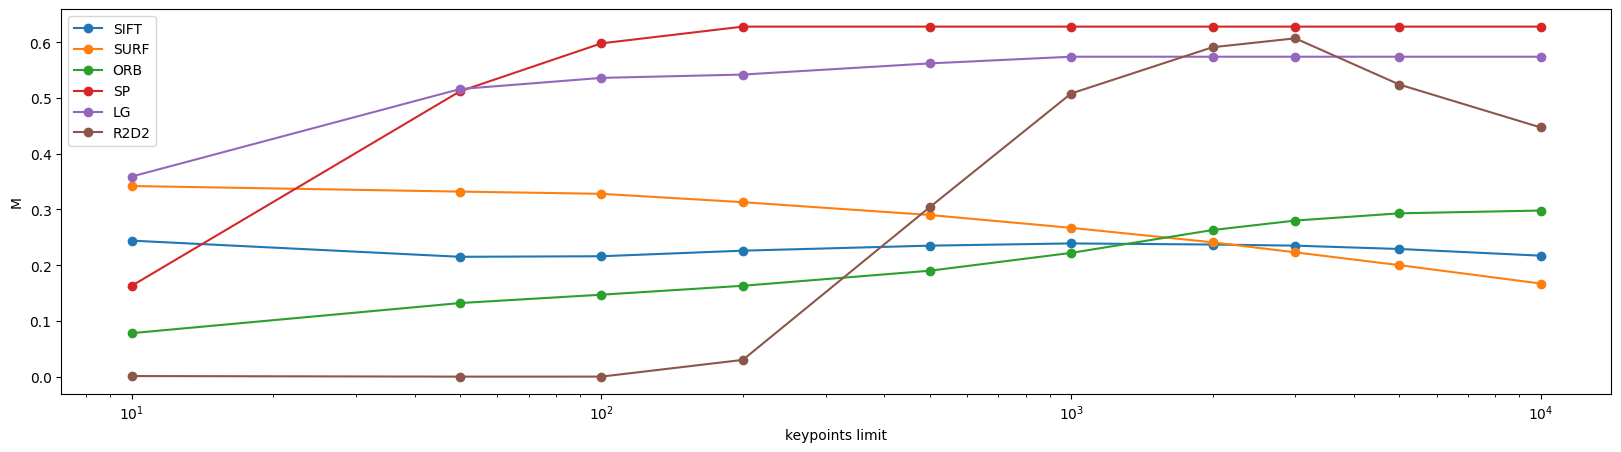

In [5]:
import matplotlib.pyplot as plt
import csv

X = []
SIFT = []
SURF = []
ORB = []
SP = []
LG = []
R2D2 = []

with open('experiment.csv', 'r') as datafile:
    plotting = csv.reader(datafile, delimiter=';')
    
    for ROWS in plotting:
        X.append(float(ROWS[0]))
        SIFT.append(float(ROWS[1]))
        SURF.append(float(ROWS[2]))
        ORB.append(float(ROWS[3]))
        SP.append(float(ROWS[4]))
        LG.append(float(ROWS[5]))
        R2D2.append(float(ROWS[6]))

fig, ax = plt.subplots(1,1, figsize=(20, 5))
ax.set_xticks(X[2:])

plt.plot(X, SIFT, marker='o', linestyle='-', label="SIFT")
plt.plot(X, SURF, marker='o', linestyle='-', label="SURF")
plt.plot(X, ORB, marker='o', linestyle='-', label="ORB")
plt.plot(X, SP, marker='o', linestyle='-', label="SP")
plt.plot(X, LG, marker='o', linestyle='-', label="LG")
plt.plot(X, R2D2, marker='o', linestyle='-', label="R2D2")

plt.xlabel('keypoints limit')
plt.ylabel('M')
plt.xscale('log')
plt.legend()
plt.show()

Получили, что метрика для SIFT достигает своего максимума примерно при ограничении 1000 ключевых точек (выделяется на каждои изображении по 1000 точек тоже). После этой отметки значение метрики плавно уменьшается.

SURF показал, что с увеличением числа точек доля правильных сопоставлений уменьшается.
Для ORB, наоборот, чем выше ограничение, тем больше точек удается верно сопоставить (думаю это связанос особеннотью ORB "кучно" выделять ключевые точки).

С помощью SuperPoint выделяется в среднем по 129 точек на каждом изображении. Поэтому дальнейшие ограничения на количество ключевых точек выше 200 никак не влияют на значение метрики. Однако значение метрики остается самым высоким среди остальных методов.

С LightGlue ситуация похожая. В среднем выделяется по 734 ключевые точки для каждого изображения и послее ограничения в 1000 точек значение метрики не изменяется.

R2D2 не находило сопоставлений вообще при малом количестве точек. От 500 и до 3000 примерно значение метрики росло, показывая достаточно хорошие результаты, а затем плавно начало снижаться.


По данной метрике получаем, что лучше всех результат показал SuperPoint, на втором месте SuperPoint + LightGlue. Однако после эксперимента мне показалось, что выбранная метрика не достаточно точна, возможно её стоит как-то улучшить, потому что SuperPoint извлекает очень мало ключевых точек (около 150), при сопоставлении их остается ещё меньше (около 100), однако  SuperPoint + LightGlue находит и сопоставляет больше точек (примерно 850 и 450). Но по итогу доля сопоставленных точек у SuperPoint оказывается выше, чем у SuperPoint + LightGlue. Хотя количество выделенных ключевых точек на изображении тоже важный показатель, как мне кажется.